# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [38]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [39]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



## New Corpus For Camparing 

In [40]:
new_corpus = '''Celebal Technologies is a technology company that helps businesses use data,
cloud services, artificial intelligence, and software solutions. The company works on real
business problems and helps clients make better decisions using data. Celebal Technologies
works in areas such as Data Science, Data Engineering, Cloud Computing, Machine Learning,
Artificial Intelligence, and Business Intelligence.
Data is important for every modern business. Companies collect data from customers, websites,
mobile applications, sales records, product systems, feedback forms, and online platforms.
This data can help a company understand customer needs, product performance, sales trends,
and business growth. Celebal Technologies helps businesses manage and use this data properly.
Data Engineering is an important area in Celebal Technologies. Data engineers collect data
from different sources such as databases, files, APIs, websites, and business applications.
They clean the data, remove duplicate records, fix missing values, change data formats, and
store the data in a useful location. This helps companies use correct and reliable data.
Data engineers also build data pipelines. A data pipeline moves data from one system to another
system. For example, a company may receive sales data from many stores every day. The pipeline
can collect the sales data, clean the records, combine the files, and store the final data in
a database or cloud platform. This process saves time and reduces manual work.
SQL is an important skill for Data Engineering. SQL helps data engineers work with databases.
They can select data, filter data, join tables, group records, and calculate values using SQL.
Python is also useful because it can automate data processing tasks and connect different systems.
Data Science is another important area in Celebal Technologies. Data scientists study data and
find patterns, trends, and useful information. They use data to answer business questions.
For example, a company may want to know why sales are decreasing, which product is performing
better, or which customers may stop using a service.
Data scientists use tools such as Python, SQL, pandas, NumPy, Matplotlib, Power BI, and machine
learning libraries. Python is used for data cleaning, data analysis, visualization, and model
building. SQL is used to get data from databases. Power BI is used to create dashboards and reports.
Data cleaning is an important step in a Data Science project. Raw data may have missing values,
duplicate rows, wrong values, or different formats. A data scientist needs to clean the data
before using it for analysis or machine learning. Good data can improve the quality of results.
Data visualization helps people understand data easily. Charts, graphs, and dashboards can show
sales trends, customer growth, product performance, profit, and other business values. A simple
dashboard can help managers make decisions based on data instead of assumptions.
Machine Learning is used to make predictions from old data. A machine learning model learns from
previous records and gives results for new records. For example, a model can predict future sales,
customer churn, product demand, fraud risk, delivery time, or customer behavior. The model needs
good data because poor data can give poor predictions.
Celebal Technologies also uses cloud platforms to store large amounts of data and run applications.
Cloud services help businesses manage data, create reports, run machine learning models, and build
scalable systems. Cloud platforms provide storage, databases, data warehouses, analytics tools,
and computing resources for companies.
Business Intelligence is useful for understanding business performance. Business Intelligence
uses data to create reports and dashboards. A dashboard may show total sales, monthly profit,
customer growth, product demand, employee performance, and location wise results. These reports
help business teams understand what is happening in the company.
Celebal Technologies works with data engineers, data scientists, cloud engineers, developers,
business analysts, and project managers. Each person has a different role in the project.
Data engineers prepare data, data scientists analyze data, cloud engineers manage cloud services,
and developers build applications. All team members work together to complete the project.
Teamwork is important in technology projects. Team members share updates, discuss problems,
review code, test solutions, and complete tasks before deadlines. Clear communication helps
the team avoid confusion and solve problems faster. Documentation is also important because it
explains the project goal, data sources, tools used, steps followed, and final results.
Celebal Technologies helps students and freshers understand professional work. Students can learn
how real projects are planned, developed, tested, and delivered. They can improve their skills in
Python, SQL, data analysis, data engineering, cloud computing, machine learning, and teamwork.
The company focuses on continuous learning because technology changes quickly. Students and
employees need to learn new tools, new methods, and new technologies. Regular practice in Python,
SQL, data analysis, and cloud tools can help students prepare for future jobs.
Celebal Technologies uses technology to solve real business problems. The company helps clients
build data pipelines, manage databases, create dashboards, use cloud platforms, develop machine
learning models, and automate business tasks. Its work in Data Science and Data Engineering helps
businesses use data in a useful, organized, and reliable way.
'''

print(new_corpus)

Celebal Technologies is a technology company that helps businesses use data,
cloud services, artificial intelligence, and software solutions. The company works on real
business problems and helps clients make better decisions using data. Celebal Technologies
works in areas such as Data Science, Data Engineering, Cloud Computing, Machine Learning,
Artificial Intelligence, and Business Intelligence.
Data is important for every modern business. Companies collect data from customers, websites,
mobile applications, sales records, product systems, feedback forms, and online platforms.
This data can help a company understand customer needs, product performance, sales trends,
and business growth. Celebal Technologies helps businesses manage and use this data properly.
Data Engineering is an important area in Celebal Technologies. Data engineers collect data
from different sources such as databases, files, APIs, websites, and business applications.
They clean the data, remove duplicate records,

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [41]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


## Tokenization For New Corpus

In [42]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([new_corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in new_corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

new_X = input_sequences[:, :-1]
new_y = input_sequences[:, -1]

print("X shape:", new_X.shape)
print("y shape:", new_y.shape)

Vocabulary size: 286
X shape: (763, 17)
y shape: (763,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [43]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## Updated Vanilla RNN

In [44]:
updated_rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

updated_rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

updated_rnn_history = updated_rnn_model.fit(new_X, new_y, epochs=200, verbose=0)
print("Updated Vanilla RNN training completed")

Updated Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [45]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


## Updated LSTM

In [46]:
updated_lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

updated_lstm_model.compile(loss='sparse_categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

updated_lstm_history = updated_lstm_model.fit(new_X, new_y, epochs=200, verbose=0)
print("Updated LSTM training completed")

Updated LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [47]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## Updated GRU

In [48]:
updated_gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

updated_gru_model.compile(loss='sparse_categorical_crossentropy',
                          optimizer='adam',
                          metrics=['accuracy'])

updated_gru_history = updated_gru_model.fit(new_X, new_y, epochs=200, verbose=0)
print("Updated GRU training completed")

Updated GRU training completed


## 📉 Compare Training Loss

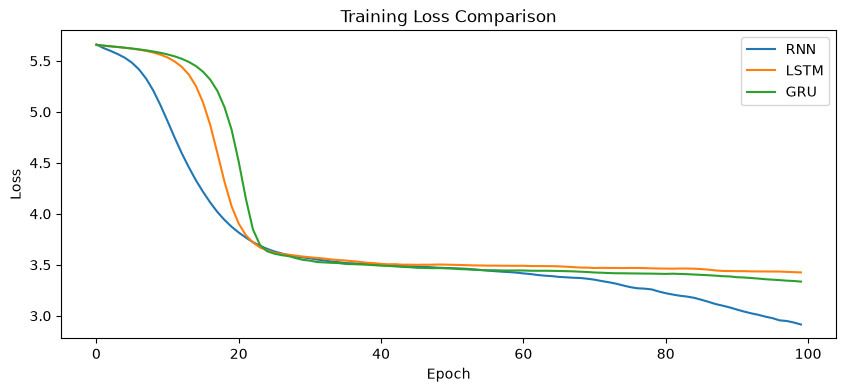

In [55]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## Camparing the Updated Models Loss

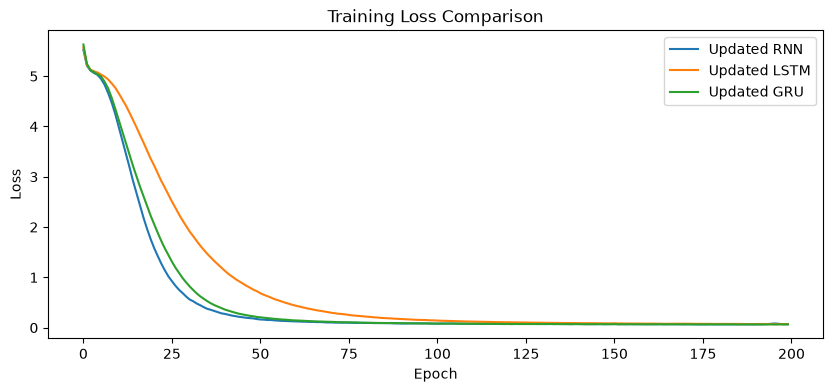

In [56]:
plt.figure(figsize=(10,4))
plt.plot(updated_rnn_history.history['loss'], label='Updated RNN')
plt.plot(updated_lstm_history.history['loss'], label='Updated LSTM')
plt.plot(updated_gru_history.history['loss'], label='Updated GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [57]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [59]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning and and and and a
LSTM: deep learning and and and and and
GRU : deep learning the the the the the


## updated Models Genrating the Tetx

In [58]:
print("RNN :", generate_text(updated_rnn_model, "Celebal Technologies", 10))
print("LSTM:", generate_text(updated_lstm_model, "Celebal Technologies", 10))
print("GRU :", generate_text(updated_gru_model, "Celebal Technologies", 10))

RNN : Celebal Technologies uses technology to solve real business problems the company helps
LSTM: Celebal Technologies also uses cloud platforms to store large amounts of data
GRU : Celebal Technologies works with data engineers data scientists cloud engineers developers developers


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**